当前工作目录: d:\Github\chuangxintou
日期: 2026-03-26 00:00:00
最后一天的收盘价:
{'000300.SH': 4477.5343, '000905.SH': 7642.1302, '000852.SH': 7639.3762, 'Unnamed: 5': nan}
估值总和: 0
共有 1 个标的:
['000852.SH']


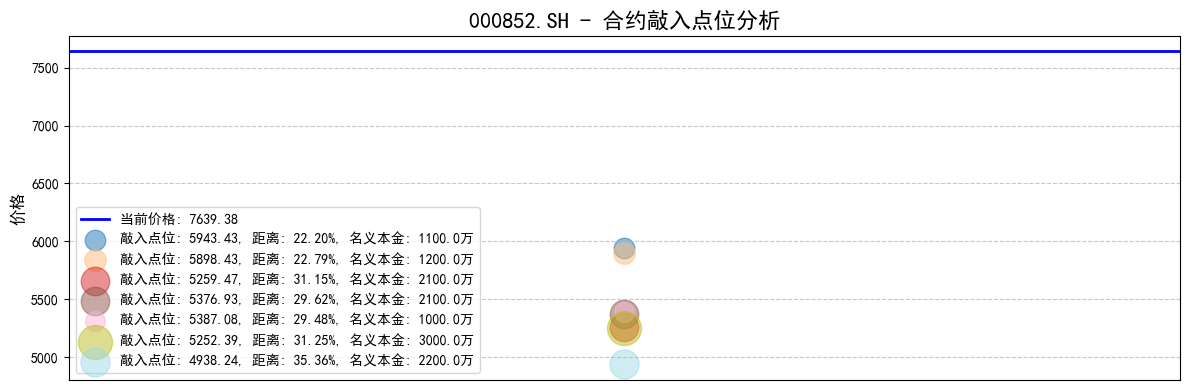

合约敲入点位分析汇总:
          标的       当前价格       敲入点位    距离敲入(%)  名义本金(万)
0  000852.SH  7639.3762  5943.4340  22.200009   1100.0
1  000852.SH  7639.3762  5898.4310  22.789102   1200.0
2  000852.SH  7639.3762  5259.4685  31.153168   2100.0
3  000852.SH  7639.3762  5376.9300  29.615588   2100.0
4  000852.SH  7639.3762  5387.0765  29.482770   1000.0
5  000852.SH  7639.3762  5252.3900  31.245826   3000.0
6  000852.SH  7639.3762  4938.2450  35.358007   2200.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置当前目录
current_dir = os.getcwd()
print(f"当前工作目录: {current_dir}")

# 读取Excel文件
excel_file = os.path.join(current_dir, '创新投雪球管理.xlsx')

# 读取合约状态sheet
df_contracts = pd.read_excel(excel_file, sheet_name='合约状态')
# print("合约状态数据:")
# print(df_contracts.head())
# print(f"\n合约状态数据形状: {df_contracts.shape}")

# 读取历史行情sheet
# 跳过前4行，从第5行开始读取数据
df_history = pd.read_excel(excel_file, sheet_name='历史行情', header=1)
# print("历史行情数据:")
# print(df_history.head())
# print(f"\n历史行情数据形状: {df_history.shape}")

# # 检查列名
# print("合约状态列名:")
# print(df_contracts.columns.tolist())

# print("\n历史行情列名:")
# print(df_history.columns.tolist())

# 提取合约信息
contract_info = df_contracts[['挂钩标的', '敲入点位', '名义本金']].copy()
# print("合约信息:")
# print(contract_info.head())
# print(f"\n合约信息形状: {contract_info.shape}")

# 获取历史行情最后一天的收盘价
# 假设第二列是日期，从第三列开始是各标的收盘价，第七列是估值总和
last_day_data = df_history.iloc[-3]
date = last_day_data.iloc[0]  # 日期
last_day_prices = {}
valuation_sum = last_day_data.iloc[6]  # 估值总和（第七列）

# 提取各标的收盘价（第三列到第六列）
for i in range(2, 6):
    if i < len(df_history.columns):
        last_day_prices[df_history.columns[i]] = last_day_data.iloc[i]

print(f"日期: {date}")
print("最后一天的收盘价:")
print(last_day_prices)
print(f"估值总和: {valuation_sum}")

# 按标的分组
underlying_assets = contract_info['挂钩标的'].unique()
print(f"共有 {len(underlying_assets)} 个标的:")
print(underlying_assets)


# 为每个标的创建图表
for asset in underlying_assets:
    # 获取该标的的所有合约
    asset_contracts = contract_info[contract_info['挂钩标的'] == asset]

    # 获取该标的当前价格
    current_price = last_day_prices.get(asset, None)

    if current_price is None:
        print(f"警告: 找不到标的 {asset} 的当前价格")
        continue

    # 创建图表
    fig, ax = plt.subplots(figsize=(12, 4))

    # 绘制当前价格线
    ax.axhline(y=current_price, color='blue', linestyle='-', linewidth=2, label=f'当前价格: {current_price:.2f}')

    # 为每个合约绘制敲入点位
    for idx, (_, contract) in enumerate(asset_contracts.iterrows()):
        knock_in = contract['敲入点位']
        nominal = contract['名义本金']

        # 计算距离敲入的百分比
        distance_to_knock_in = (current_price - knock_in) / current_price * 100

        # 为每笔合约生成不同的颜色
        # 使用颜色循环，确保每笔合约有独特的颜色
        colors = plt.cm.tab20(np.linspace(0, 1, len(asset_contracts)))
        color = colors[idx]

        # 根据距离敲入的远近设置透明度
        # 距离越近，透明度越高（越不透明）
        if distance_to_knock_in < 0:
            alpha = 1.0  # 已敲入，完全不透明
        elif distance_to_knock_in < 5:
            alpha = 0.9  # 距离敲入很近，高透明度
        elif distance_to_knock_in < 10:
            alpha = 0.7  # 距离敲入较近，中等透明度
        else:
            alpha = 0.5  # 距离敲入较远，低透明度

        # 点的大小根据名义本金调整
        size = nominal / 1000000 * 20  # 每100万对应20个点的大小

        # 绘制敲入点位
        ax.scatter(x=0, y=knock_in, s=size, color=color, alpha=alpha,
                   label=f'敲入点位: {knock_in:.2f}, 距离: {distance_to_knock_in:.2f}%, 名义本金: {nominal/10000:.1f}万')

    # 设置图表标题和标签
    ax.set_title(f'{asset} - 合约敲入点位分析', fontsize=16)
    ax.set_ylabel('价格', fontsize=12)

    # 隐藏x轴
    ax.set_xticks([])

    # 添加图例
    ax.legend(loc='best')

    # 添加网格
    ax.grid(True, linestyle='--', alpha=0.7)

    # 显示图表
    plt.tight_layout()
    plt.savefig(f'IMAGES\{asset}_contract_knock_in_analysis.png')
    plt.show()

# 汇总分析结果
summary_data = []
for asset in underlying_assets:
    asset_contracts = contract_info[contract_info['挂钩标的'] == asset]
    current_price = last_day_prices.get(asset, None)

    if current_price is None:
        continue

    for _, contract in asset_contracts.iterrows():
        knock_in = contract['敲入点位']
        nominal = contract['名义本金']
        distance_to_knock_in = (current_price - knock_in) / current_price * 100

        summary_data.append({
            '标的': asset,
            '当前价格': current_price,
            '敲入点位': knock_in,
            '距离敲入(%)': distance_to_knock_in,
            '名义本金(万)': nominal/10000
        })

summary_df = pd.DataFrame(summary_data)
print("合约敲入点位分析汇总:")
print(summary_df)


当前工作目录: d:\Github\chuangxintou

添加估值总和列名后的历史行情数据:
Index(['date', '000016.SH', '000300.SH', '000905.SH', '000852.SH',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', '估值总和'],
      dtype='object')
找到日期: 2025-12-31 00:00:00
d:\Github\chuangxintou d:\Github\chuangxintou\IMAGES\dividend_plot.png


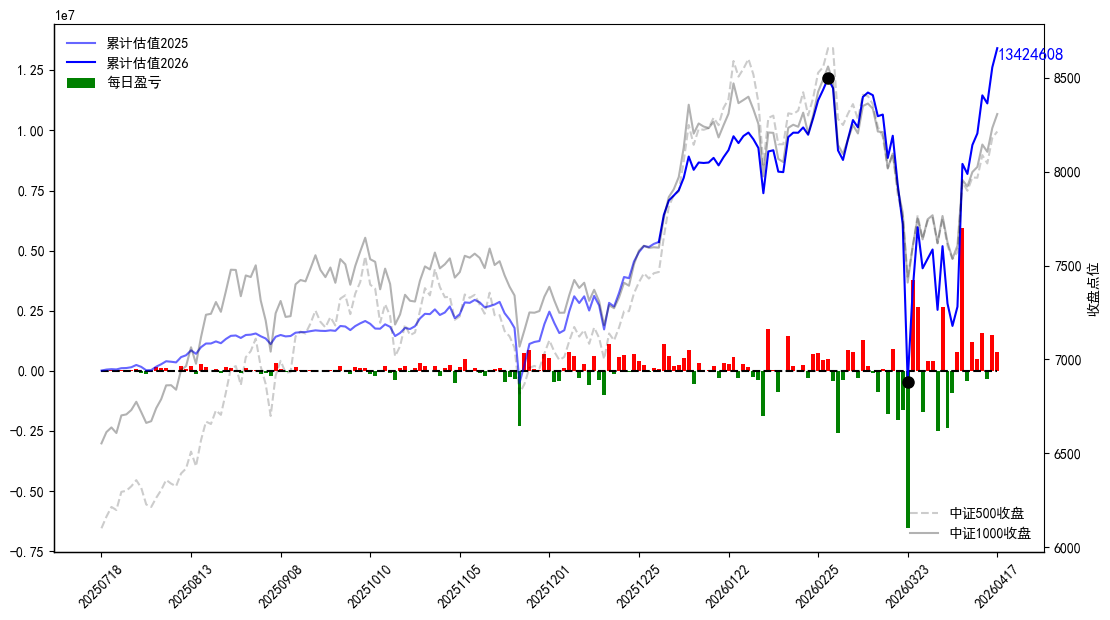

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import os
import warnings
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置当前目录
current_dir = os.getcwd()
folder_path = current_dir

print(f"当前工作目录: {current_dir}")

# 读取Excel文件
excel_file = os.path.join(current_dir, '创新投雪球管理.xlsx')

# 读取历史行情sheet
# 第1行是列名，从第4行开始读取数据（header=1，因为pandas从0开始计数）
df_history = pd.read_excel(excel_file, sheet_name='历史行情', header=1)
# print("原始历史行情数据:")
# print(df_history.head())
# print(f"\n原始历史行情数据形状: {df_history.shape}")

# 删除前两行（第2行和第3行是没用的）
df_history = df_history.iloc[2:].reset_index(drop=True)
# print("\n删除前两行后的历史行情数据:")
# print(df_history.head())
# print(f"\n删除前两行后的历史行情数据形状: {df_history.shape}")

# 给第0列添加"date"列名
df_history.columns = ['date'] + list(df_history.columns[1:])
# print("\n添加date列名后的历史行情数据:")
# print(df_history.head())

# 给第9列添加"估值总和"列名
if len(df_history.columns) > 11:
    df_history.columns = list(df_history.columns[:11]) + ['估值总和'] + list(df_history.columns[12:])
    print("\n添加估值总和列名后的历史行情数据:")
    # print(df_history.head())

# 删除最后两行
df_history = df_history.iloc[:-2]
# print("\n删除最后两行后的历史行情数据:")
# print(df_history.head())
# print(f"\n删除最后两行后的历史行情数据形状: {df_history.shape}")

# 确保日期列是datetime类型
df_history['date'] = pd.to_datetime(df_history['date'])

# 计算每天的涨跌
# df_history['涨跌'] = df_history['估值总和'].diff()

def maximum_drawdown(prices):
    """
    计算最大回撤及其区间。

    :param prices: 股票价格序列（列表或NumPy数组）
    :return: 最大回撤值和最大回撤区间（开始索引和结束索引）
    """
    # 转换为 NumPy 数组
    prices = np.array(prices)
    
    # 示例使用
    cumulative_sum = prices.cumsum()  # 计算积分

    data =np.array( cumulative_sum)
    # max_dd, (start, end) = maximum_drawdown(prices)

    index_j = np.argmax(np.maximum.accumulate(data) - data)  # 结束位置
    # print(index_j)                      ###maximum loss
    index_i = np.argmax(data[:index_j])  # 开始位置
    # print(index_i)                       ##maximum gain
    d = data[index_j] - data[index_i]  # 最大回撤
    return(d, index_i, index_j)

def plot_dividend(df):


    # df.rename(columns={ "估值":"估值总和", '日期':"date"}, inplace=True)
    print(df.columns)
    df['PV'] = df['估值总和']
    df['PV_DIFF'] = df['估值总和'].diff()
    df.loc[0, 'PV_DIFF'] = 0
    # print(df.head())


    times_str = []
    tt = df['date']
    for t in tt:
        times_str.append(t.strftime('%Y%m%d'))
    # 查找特定日期
    target_date = '20251231'  # 要寻找的日期
    if target_date in times_str:
        index = times_str.index(target_date)
        found_date = df['date'].iloc[index]
        print(f"找到日期: {found_date}")
    else:
        print("未找到日期 2025-12-31")

    fig = plt.figure(figsize=( 16*0.7, 9*0.7))
    gs = GridSpec(nrows=1, ncols=1)#, width_ratios=[3, 1, 1, 0], height_ratios=[1, 1])

    # 第一个子图：绘制 qdt 列的散点图

    ax1 = fig.add_subplot(gs[0, 0])  # 第一行，占据前 3 列ax3 = fig.add_subplot(2,1)
    colors = ['red' if value > 0 else 'green' for value in  df['PV_DIFF']]
    line1 = ax1.bar(times_str, df['PV_DIFF'], label = '每日盈亏', color = colors)
    ax1.plot(times_str, df['PV'] * 0, 'k--')
    ax1.text(times_str[-1], df['PV'].iloc[-1],f'{round(df["PV"].iloc[-1]):d}', fontsize=12, color='blue', verticalalignment='top')
    data =np.array( df['PV'])
    # print('近一个月累积收益：' , data[-1])

    # ax1.plot(times_str,  df['PV'], 'b', label='累计估值')
    line2 = ax1.plot(times_str[:index+1],  df['PV'][:index+1], 'b',alpha = 0.6, label='累计估值2025')
    line3 = ax1.plot(times_str[index:],  df['PV'][index:], 'b',alpha = 1, label='累计估值2026')

    down, index_i, index_j = maximum_drawdown(df['PV_DIFF'])
    ax1.plot([index_i, index_j], [data[index_i], data[index_j]], 'o', color="k", markersize=8)
    itv = int(len(df)/10)
    if len(df)>63:
        pass
    else:
        itv =1
    # 设置每 60 个数据点一个 xtick
    ax1.set_xticks(times_str[::itv])
    ax1.set_xticklabels(times_str[::itv], rotation=45)
    # ax1.grid(True)
    # yticks = ax1.get_yticks()
    # ax1.set_yticklabels([f'{val/1e7:.2f}千万' for val in yticks])
    ax1.legend(loc='upper left',frameon=False)
    # lines = [line1, line2, line3]  # 将两条线的 Handles 组合在一起
    # labels = [line1.get_label(), line2.get_label(), line3.get_label()]  # 获取每条线的标签
    close   = 1
    if close:
        # 创建共享 X 轴的右侧 Y 轴
        ax2 = ax1.twinx()  # 创建一个共享 X 轴的新轴
        line4 = ax2.plot(times_str, df['000905.SH'], 'k--',alpha = 0.2, label='中证500收盘')
        line5 = ax2.plot(times_str, df['000852.SH'], color='k',alpha = 0.3, label='中证1000收盘')
        ax2.set_ylabel('收盘点位')
        ax2.legend(loc='lower right',frameon=False)
        # lines = [line1, line2, line3, line4, line5]  # 将两条线的 Handles 组合在一起
        # labels = [line1.get_label(), line2.get_label(), line3.get_label(),line4.get_label(), line5.get_label()]  # 获取每条线的标签
    # 设置背景色和边框
    plt.gca().patch.set_facecolor('#ffffff')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.gca().spines['left'].set_linewidth(1)

    plt.tight_layout()
    print(folder_path, os.path.join(folder_path, 'IMAGES\\dividend_plot.png'))
    plt.savefig(os.path.join(folder_path, 'IMAGES\\dividend_plot.png'), dpi=300)
plot_dividend(df_history)